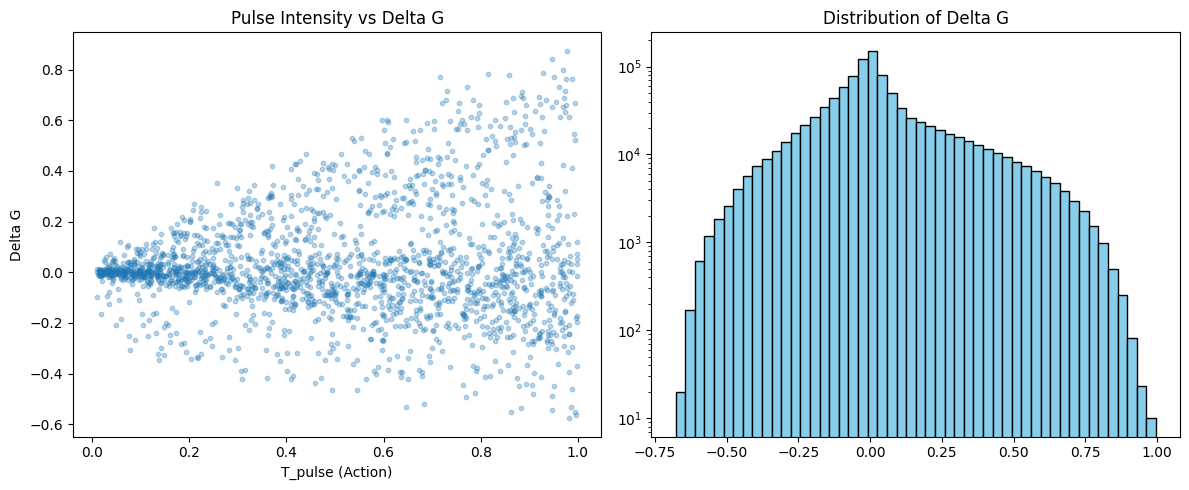

In [3]:
import matplotlib.pyplot as plt
import torch

def plot_physics(path='data/raw_data.pt'):
    data = torch.load(path)
    
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(data['t_pulse'][:2000], data['delta_g'][:2000], alpha=0.3, s=10)
    plt.title("Pulse Intensity vs Delta G")
    plt.xlabel("T_pulse (Action)")
    plt.ylabel("Delta G")

    plt.subplot(1, 2, 2)
    plt.hist(data['delta_g'], bins=50, color='skyblue', edgecolor='black')
    plt.title("Distribution of Delta G")
    plt.yscale('log')

    plt.tight_layout()

if __name__ == "__main__":
    plot_physics()

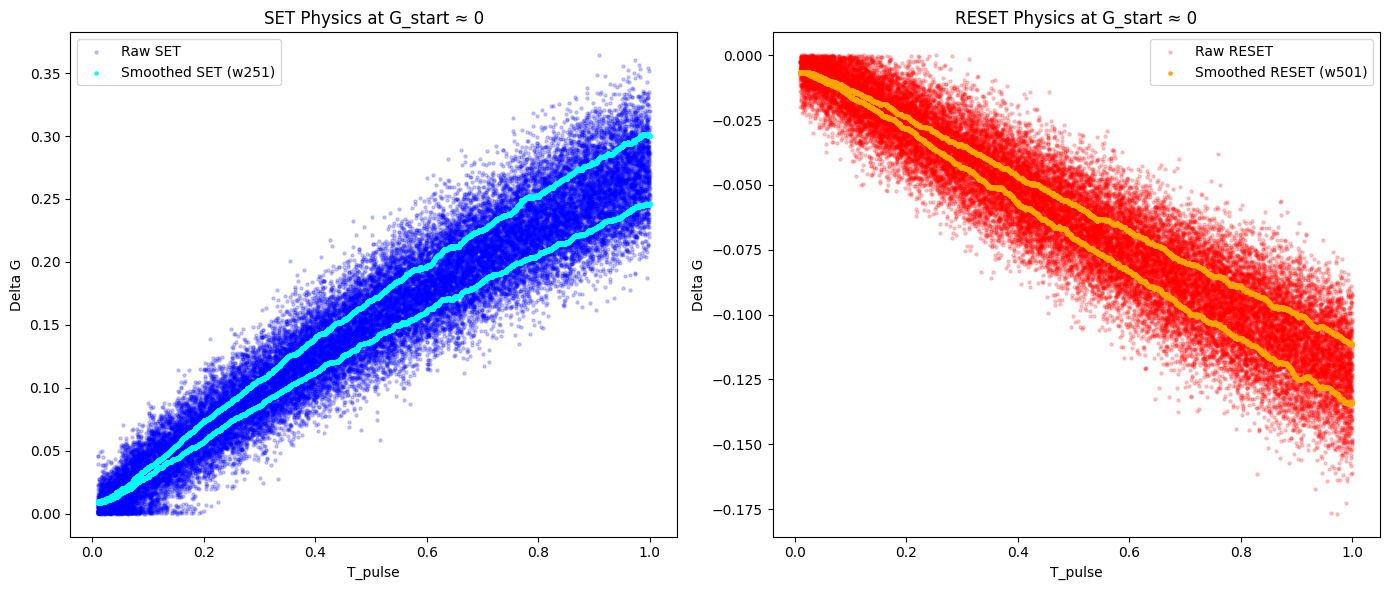

In [4]:
import torch
import matplotlib.pyplot as plt

def plot_true_physics(raw_path='data/raw_data.pt', smooth_path='data/smoothed_data_w501.pt'):
    raw = torch.load(raw_path)
    smooth = torch.load(smooth_path)

    plt.figure(figsize=(14, 6))

    mask_raw_mid = (raw['g_start'] > -0.1) & (raw['g_start'] < 0.1)
    mask_smooth_mid = (smooth['g_start'] > -0.1) & (smooth['g_start'] < 0.1)

    plt.subplot(1, 2, 1)
    mask_raw_set = mask_raw_mid & (raw['delta_g'] >= 0)
    mask_smooth_set = mask_smooth_mid & (smooth['delta_g'] >= 0)
    
    plt.scatter(raw['t_pulse'][mask_raw_set], raw['delta_g'][mask_raw_set], 
                color='blue', alpha=0.2, label='Raw SET', s=5)
    plt.scatter(smooth['t_pulse'][mask_smooth_set], smooth['delta_g'][mask_smooth_set], 
                color='cyan', alpha=1.0, label='Smoothed SET (w251)', s=5)
    
    plt.title("SET Physics at G_start ≈ 0")
    plt.xlabel("T_pulse")
    plt.ylabel("Delta G")
    plt.legend()

    plt.subplot(1, 2, 2)
    mask_raw_reset = mask_raw_mid & (raw['delta_g'] < 0)
    mask_smooth_reset = mask_smooth_mid & (smooth['delta_g'] < 0)

    plt.scatter(raw['t_pulse'][mask_raw_reset], raw['delta_g'][mask_raw_reset], 
                color='red', alpha=0.2, label='Raw RESET', s=5)
    plt.scatter(smooth['t_pulse'][mask_smooth_reset], smooth['delta_g'][mask_smooth_reset], 
                color='orange', alpha=1.0, label='Smoothed RESET (w501)', s=5)

    plt.title("RESET Physics at G_start ≈ 0")
    plt.xlabel("T_pulse")
    plt.ylabel("Delta G")
    plt.legend()

    plt.tight_layout()

if __name__ == "__main__":
    plot_true_physics()

--- Validation Results ---
MSE: 0.032925
Average RPD: 34.91%
Median RPD: 18.45%


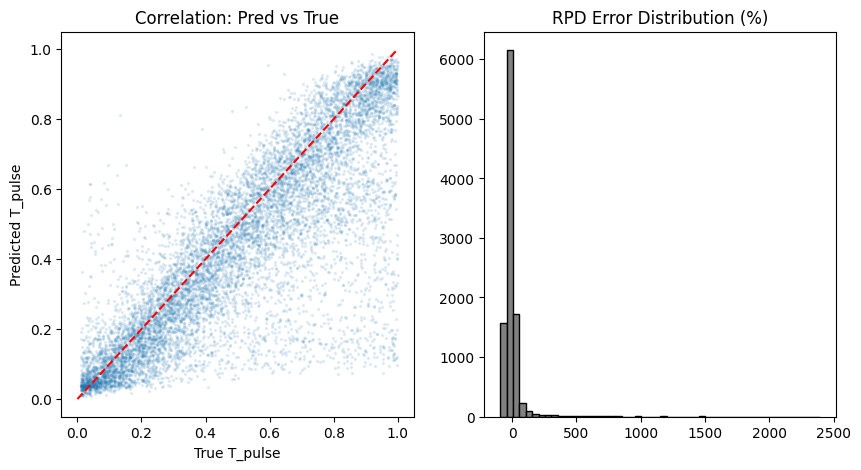

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from model import NPPModel

def validate_npp(data_path='data/raw_data.pt', model_path='npp_final.pth'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = NPPModel().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    data = torch.load(data_path)
    test_gs = data['g_start'][-10000:].view(-1, 1).to(device)
    test_dg = data['delta_g'][-10000:].view(-1, 1).to(device)
    test_tp = data['t_pulse'][-10000:].view(-1, 1).to(device)

    with torch.no_grad():
        preds = model(test_gs, test_dg)
    
    preds = preds.cpu().numpy()
    targets = test_tp.cpu().numpy()

    mse = np.mean((preds - targets)**2)
    mask = targets > 0.01
    rpd = np.mean(np.abs(preds[mask] - targets[mask]) / targets[mask]) * 100

    print(f"--- Validation Results ---")
    print(f"MSE: {mse:.6f}")
    print(f"Average RPD: {rpd:.2f}%")
    rpd_median = np.median(np.abs(preds[mask] - targets[mask]) / targets[mask]) * 100
    print(f"Median RPD: {rpd_median:.2f}%")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(targets, preds, alpha=0.1, s=2)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.title("Correlation: Pred vs True")
    plt.xlabel("True T_pulse")
    plt.ylabel("Predicted T_pulse")

    plt.subplot(1, 2, 2)
    errors = (preds[mask] - targets[mask]) / targets[mask] * 100
    plt.hist(errors, bins=50, color='gray', edgecolor='black')
    plt.title("RPD Error Distribution (%)")

if __name__ == "__main__":
    validate_npp()